# Showcasing Pathfinder for the different radar systems

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath('../Pathfinder'))

from helper_functions import *
from radar_functions import *
from pathfinder import *
from attach_grounddata import *
from add_dataflashlog import *
from clicki_tool import *

%matplotlib inline

### Loading all the RADAR objects

In [2]:
path = "../Data/AWI/your_RADAR_object.pkl" #this was created in make_RADAR.ipynb. Pathfinder has been run in ht fig09_Pathfinder_otherRadars.ipynb
RADAR_AWI = load_RADAR(path=path) 

path = "../Data/GEORESEARCH/your_RADAR_object.pkl"
RADAR_GR = load_RADAR(path=path)

path = "../Data/Kiwi/your_RADAR_object.pkl"
RADAR_KIWI = load_RADAR(path=path)

Dataset  from campaign  is loaded from ../Data/AWI/your_RADAR_object.pkl
Dataset  from campaign  is loaded from ../Data/GEORESEARCH/your_RADAR_object.pkl
Dataset  from campaign  is loaded from ../Data/Kiwi/your_RADAR_object.pkl


Text(0.01, 0.97, 'c)')

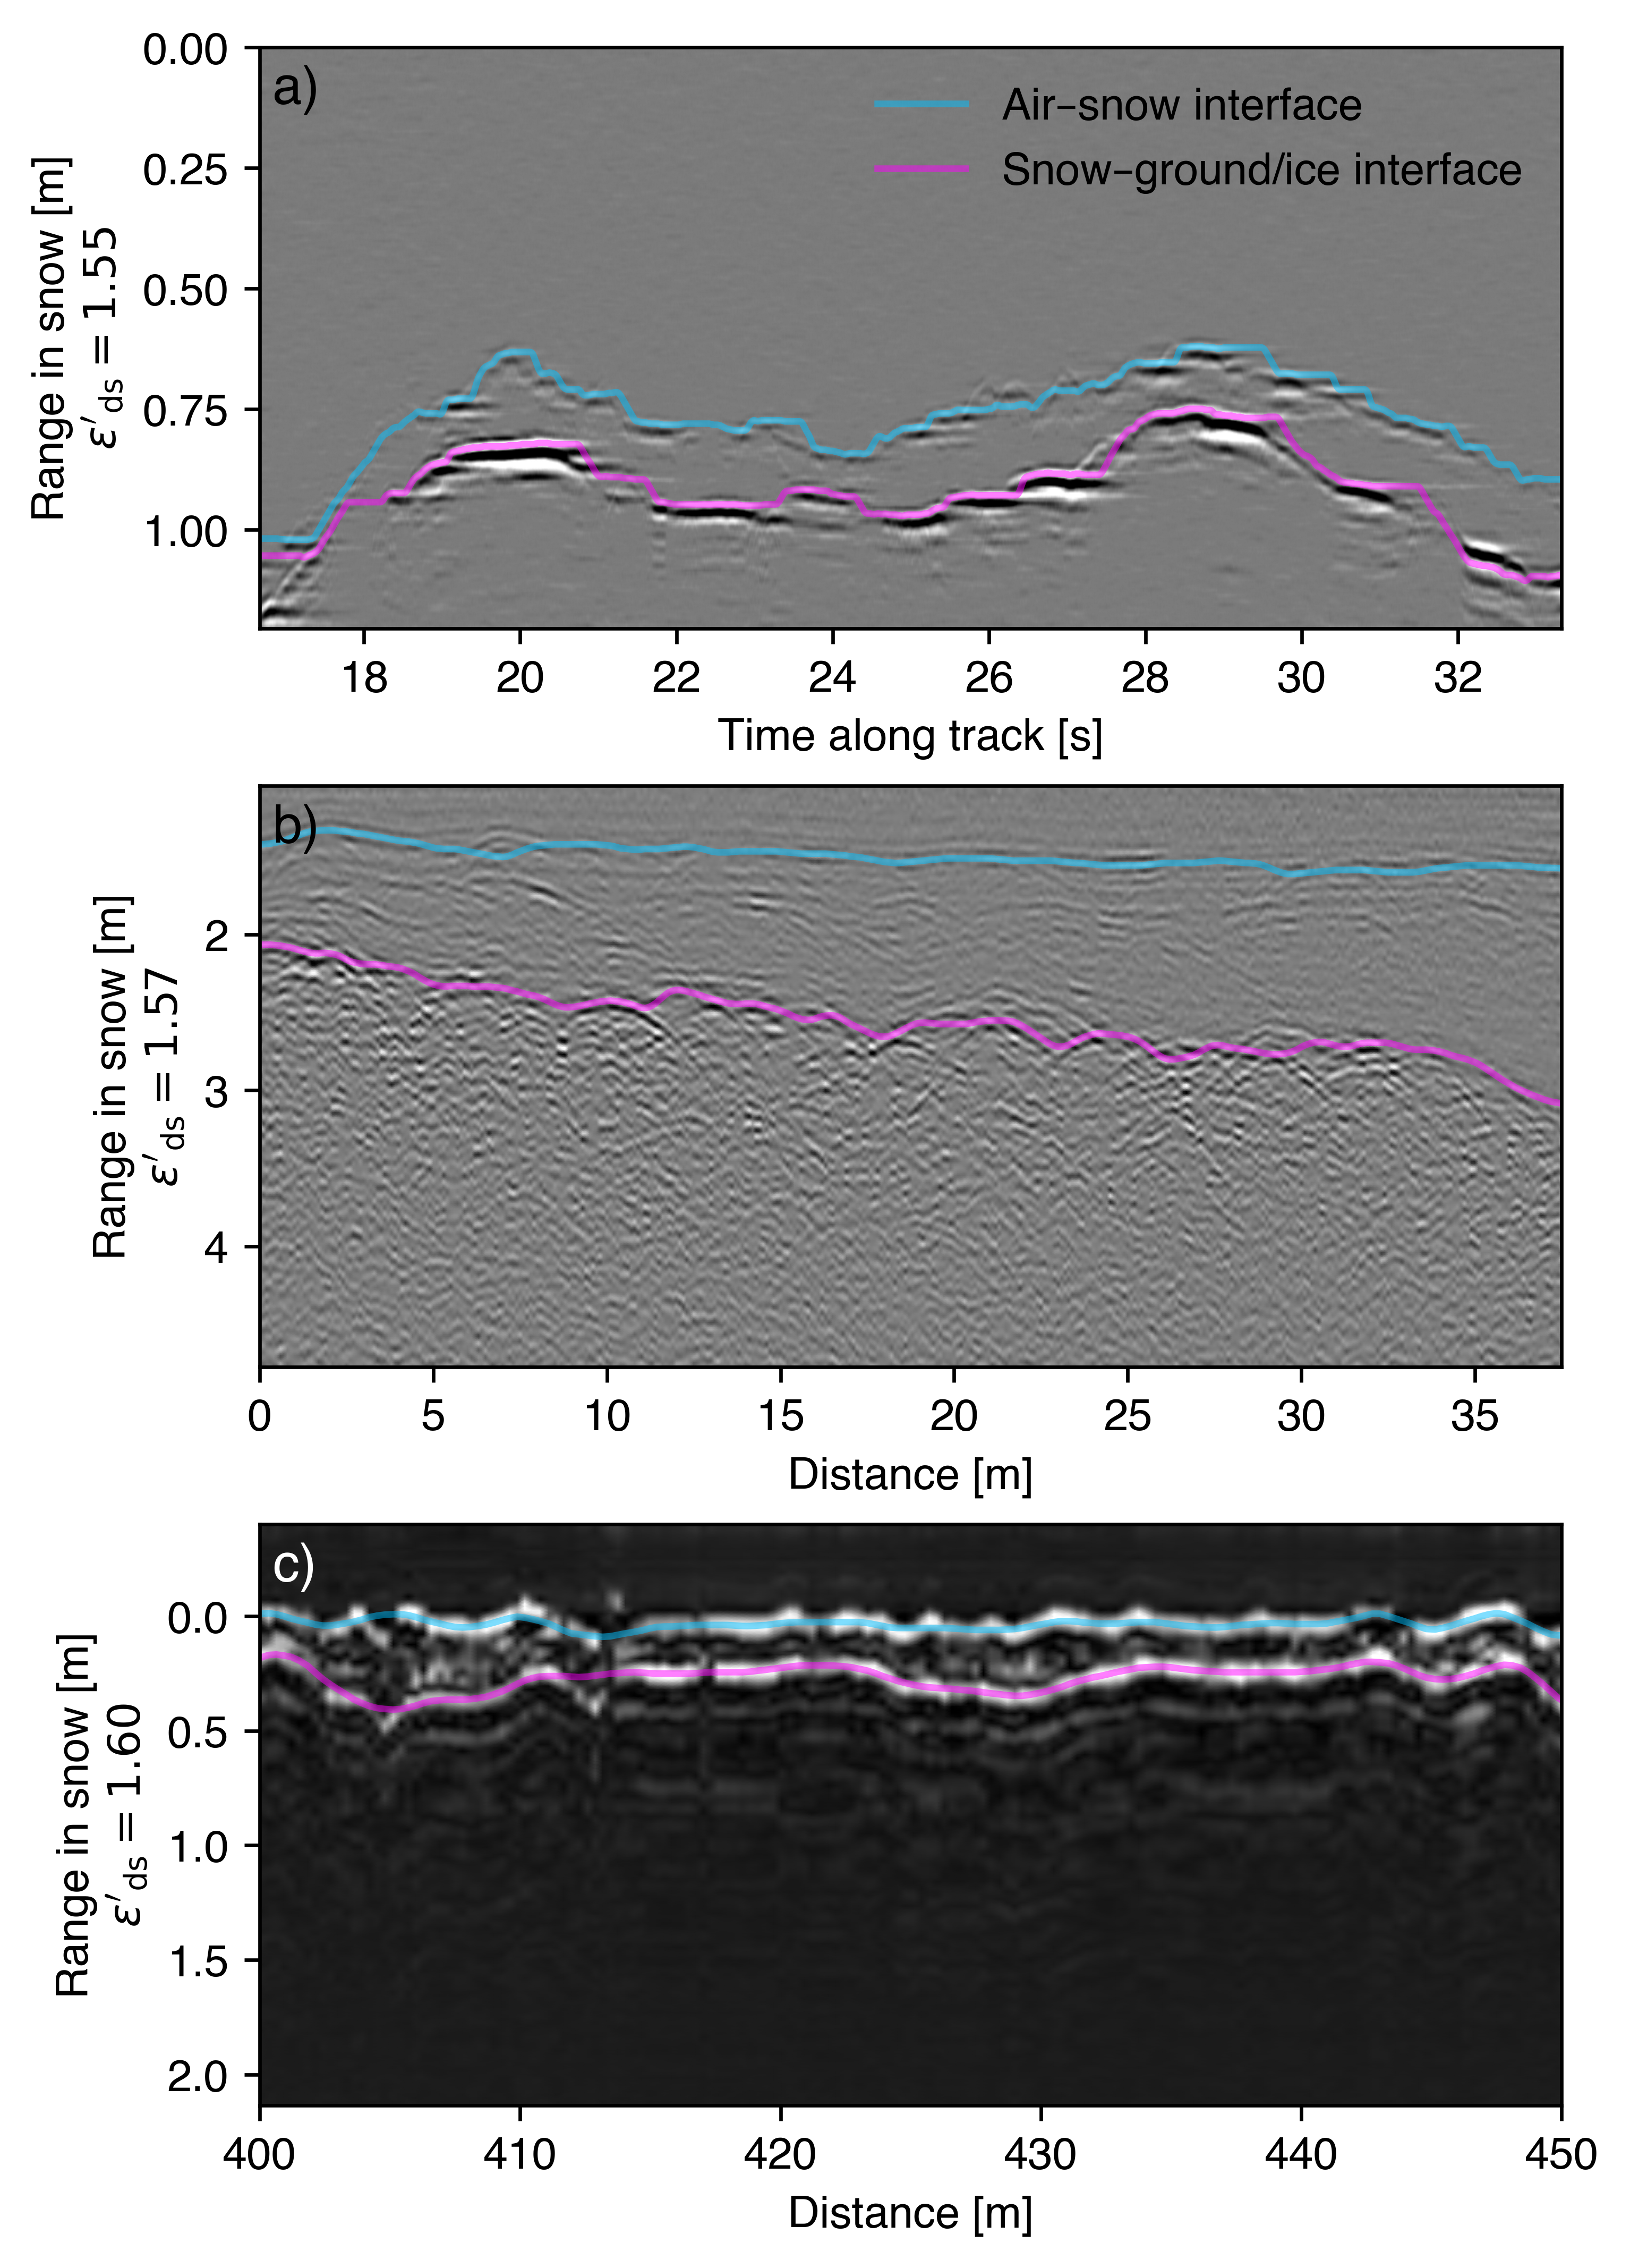

In [4]:
fig, ax = plt.subplots(3,1, figsize=(5,7), constrained_layout=True, dpi=600)

#AWI
ax[0].pcolormesh(RADAR_AWI.slowtime[2000:4000], RADAR_AWI.range_snow, RADAR_AWI.rx_rpca, cmap='gray',shading='gouraud',
                 vmin=np.nanquantile(RADAR_AWI.rx_rpca, 0.005), vmax=np.nanquantile(RADAR_AWI.rx_rpca, 0.995)
                 )
ax[0].plot(RADAR_AWI.slowtime[2000:4000], pd.Series([RADAR_AWI.range_snow[i] for i in RADAR_AWI.PF_top_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='deepskyblue',
           linewidth=1.5,
           alpha=.5,
           label='Air$\\endash$snow interface'
           )
ax[0].plot(RADAR_AWI.slowtime[2000:4000], pd.Series([RADAR_AWI.range_snow[i] for i in RADAR_AWI.PF_bottom_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='magenta',
           linewidth=1.5,
           alpha=.5,
           label='Snow$\\endash$ground/ice interface'
           )
ax[0].set_ylabel("Range in snow [m]\n$\\varepsilon'_\mathrm{ds} = 1.55$")
ax[0].set_xlabel("Time along track [s]")
ax[0].invert_yaxis()
ax[0].legend(loc='upper right', frameon=False)

#GEORESEARCH
ax[1].pcolormesh(np.arange(0, len(RADAR_GR.PF_bottom_interface) * 0.1, 0.1), RADAR_GR.range_snow, Quickboost(RADAR_GR.rx_rpca,0.05), cmap='gray', shading='gouraud')
ax[1].plot(np.arange(0, len(RADAR_GR.PF_bottom_interface) * 0.1, 0.1), pd.Series([RADAR_GR.range_snow[i] for i in RADAR_GR.PF_top_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='deepskyblue',
           linewidth=1.5,
           alpha=.5
           )
ax[1].plot(np.arange(0, len(RADAR_GR.PF_bottom_interface) * 0.1, 0.1), pd.Series([RADAR_GR.range_snow[i] for i in RADAR_GR.PF_bottom_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='magenta',
           linewidth=1.5,
           alpha=.5
           )
ax[1].invert_yaxis()
ax[1].set_ylabel("Range in snow [m]\n$\\varepsilon'_\mathrm{ds} = 1.57$")
ax[1].set_xlabel("Distance [m]")

#KIWI
ax[2].pcolormesh(RADAR_KIWI.dist, RADAR_KIWI.range_air, RADAR_KIWI.rx_rpca, cmap='gray',
                 vmin=np.nanquantile(RADAR_KIWI.rx_rpca, 0.005), vmax=np.nanquantile(RADAR_KIWI.rx_rpca, 0.995),
                 shading='gouraud'
                 )
ax[2].plot(RADAR_KIWI.dist, pd.Series([RADAR_KIWI.range_air[i] for i in RADAR_KIWI.PF_top_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='deepskyblue',
           linewidth=1.5,
           alpha=.5
           )
ax[2].plot(RADAR_KIWI.dist, pd.Series([RADAR_KIWI.range_air[i] for i in RADAR_KIWI.PF_bottom_interface]).rolling(center=True, window=7, min_periods=1).mean(),
           color='magenta',
           linewidth=1.5,
           alpha=.5
           )
ax[2].invert_yaxis()
ax[2].set_ylabel("Range in snow [m]\n$\\varepsilon'_\mathrm{ds} = 1.60$")
ax[2].set_xlabel("Distance [m]")
ax[2].set_xlim(400, 450)


ax[0].text(0.01, 0.97, 'a)', transform=ax[0].transAxes, verticalalignment='top', horizontalalignment='left', fontsize=12)
ax[1].text(0.01, 0.97, 'b)', transform=ax[1].transAxes, verticalalignment='top', horizontalalignment='left', fontsize=12)
ax[2].text(0.01, 0.97, 'c)', transform=ax[2].transAxes, verticalalignment='top', horizontalalignment='left', fontsize=12, color='white')


In [5]:
fig.savefig('./export/fig08.pdf', dpi=600)
